# Bondora Data Preprocessing

In this project we will be doing credit risk modelling of peer to peer lending Bondora systems.Data for the study has been retrieved from a publicly available data set of a leading European P2P lending platform  ([**Bondora**](https://www.bondora.com/en/public-reports#dataset-file-format)).The retrieved data is a pool of both defaulted and non-defaulted loans from the time period between **1st March 2009** and **27th January 2020**. The data
comprises of demographic and financial information of borrowers, and loan transactions.In P2P lending, loans are typically uncollateralized and lenders seek higher returns as a compensation for the financial risk they take. In addition, they need to make decisions under information asymmetry that works in favor of the borrowers. In order to make rational decisions, lenders want to minimize the risk of default of each lending decision, and realize the return that compensates for the risk.

In this notebook we will preprocess the raw dataset and will create new preprocessed csv that can be used for building credit risk models.

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df=pd.read_csv(r'/content/drive/MyDrive/Research/Paper: Enhancing Default Prediction in P2P Lending with Deep Model Fusion/Source Code/data/raw/Bondora_raw.csv')

/tmp/ipykernel_894/935774681.py:1: DtypeWarning: Columns (34,37,38,80,82,83,89,90) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r'/content/drive/MyDrive/Research/Paper: Enhancing Default Prediction in P2P Lending with Deep Model Fusion/Source Code/data/raw/Bondora_raw.csv')


In [33]:
df.shape

(134529, 112)

In [34]:
df['Status'].value_counts()

,count
Status,
Current,57135
Late,45772
Repaid,31622


In [35]:
df.head()

,ReportAsOfEOD,LoanId,LoanNumber,ListedOnUTC,BiddingStartedOn,BidsPortfolioManager,BidsApi,BidsManual,UserName,NewCreditCustomer,...,PreviousEarlyRepaymentsCountBeforeLoan,GracePeriodStart,GracePeriodEnd,NextPaymentDate,NextPaymentNr,NrOfScheduledPayments,ReScheduledOn,PrincipalDebtServicingCost,InterestAndPenaltyDebtServicingCost,ActiveLateLastPaymentCategory
0,2020-01-27,F0660C80-83F3-4A97-8DA0-9C250112D6EC,659,2009-06-11 16:40:39,2009-06-11 16:40:39,0,0,115.0410,KARU,True,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
1,2020-01-27,978BB85B-1C69-4D51-8447-9C240104A3A2,654,2009-06-10 15:48:57,2009-06-10 15:48:57,0,0,140.6057,koort681,False,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
2,2020-01-27,EA44027E-7FA7-4BB2-846D-9C1F013C8A22,641,2009-06-05 19:12:29,2009-06-05 19:12:29,0,0,319.5580,0ie,True,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,180+
3,2020-01-27,CE67AD25-2951-4BEE-96BD-9C2700C61EF4,668,2009-06-13 12:01:20,2009-06-13 12:01:20,0,0,57.5205,Alyona,True,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
4,2020-01-27,9408BF8C-B159-4D6A-9D61-9C2400A986E3,652,2009-06-10 10:17:13,2009-06-10 10:17:13,0,0,319.5582,Kai,True,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,180+


## Data Understanding

| Feature                                | Description                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
|----------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| ActiveLateCategory                     | When a loan is in Principal Debt then it will be categorized by Principal Debt days                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| ActiveLateLastPaymentCategory          | Shows how many days has passed since last payment and categorised if it is overdue                                                                                                                                                                                                                                                                                                                                                                                                                                  |
| ActiveScheduleFirstPaymentReached      | Whether the first payment date has been reached according to the active schedule                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| Age                                    | The age of the borrower when signing the loan application                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| Amount                                 | Amount the borrower received on the Primary Market. This is the principal balance of your purchase from Secondary Market                                                                                                                                                                                                                                                                                                                                                                                            |
| AmountOfPreviousLoansBeforeLoan        | Value of previous loans                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| AppliedAmount                          | The amount borrower applied for originally                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| AuctionBidNumber                       | Unique bid number which is accompanied by Auction number                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
| AuctionId                              | A unique number given to all auctions                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| AuctionName                            | Name of the Auction, in newer loans it is defined by the purpose of the loan                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| AuctionNumber                          | Unique auction number which is accompanied by Bid number                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
| BidPrincipal                           | On Primary Market BidPrincipal is the amount you made your bid on. On Secondary Market BidPrincipal is the purchase price                                                                                                                                                                                                                                                                                                                                                                                           |
| BidsApi                                | The amount of investment offers made via Api                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| BidsManual                             | The amount of investment offers made manually                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| BidsPortfolioManager                   | The amount of investment offers made by Portfolio Managers                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| BoughtFromResale_Date                  | The time when the investment was purchased from the Secondary Market                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| City                                   | City of the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| ContractEndDate                        | The date when the loan contract ended                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| Country                                | Residency of the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| County                                 | County of the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| CreditScoreEeMini                      | 1000 No previous payments problems 900 Payments problems finished 24-36 months ago 800 Payments problems finished 12-24 months ago 700 Payments problems finished 6-12 months ago 600 Payment problems finished < 6 months ago 500 Active payment problems                                                                                                                                                                                                                                                          |
| CreditScoreEsEquifaxRisk               | Generic score for the loan applicants that do not have active past due operations in ASNEF; a measure of the probability of default one year ahead; the score is given on a 6-grade scale: AAA (“Very low”), AA (“Low”), A (“Average”), B (“Average High”), C (“High”), D (“Very High”).                                                                                                                                                                                                                            |
| CreditScoreEsMicroL                    | A score that is specifically designed for risk classifying subprime borrowers (defined by Equifax as borrowers that do not have access to bank loans); a measure of the probability of default one month ahead; the score is given on a 10-grade scale, from the best score to the worst: M1, M2, M3, M4, M5, M6, M7, M8, M9, M10.                                                                                                                                                                                  |
| CreditScoreFiAsiakasTietoRiskGrade     | Credit Scoring model for Finnish Asiakastieto RL1 Very low risk 01-20 RL2 Low risk 21-40 RL3 Average risk 41-60 RL4 Big risk 61-80 RL5 Huge risk 81-100                                                                                                                                                                                                                                                                                                                                                             |
| CurrentDebtDaysPrimary                 | How long the loan has been in Principal Debt                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| CurrentDebtDaysSecondary               | How long the loan has been in Interest Debt                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| DateOfBirth                            | The date of the borrower's birth                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| DebtOccuredOn                          | The date when Principal Debt occurred                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| DebtOccuredOnForSecondary              | The date when Interest Debt occurred                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| DebtToIncome                           | Ratio of borrower's monthly gross income that goes toward paying loans                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| DefaultDate                            | The date when loan went into defaulted state and collection process was started                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| DesiredDiscountRate                    | Investment being sold at a discount or premium                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| EAD1                                   | Exposure at default, outstanding principal at default                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| EAD2                                   | Exposure at default, loan amount less all payments prior to default                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| Education                              | 1 Primary education 2 Basic education 3 Vocational education 4 Secondary education 5 Higher education                                                                                                                                                                                                                                                                                                                                                                                                               |
| EL_V0                                  | Expected loss calculated by the specified version of Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| EL_V1                                  | Expected loss calculated by the specified version of Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| EL_V2                                  | Expected loss calculated by the specified version of Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| EmploymentDurationCurrentEmployer      | Employment time with the current employer                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| EmploymentPosition                     | Employment position with the current employer                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| EmploymentStatus                       | 1 Unemployed 2 Partially employed 3 Fully employed 4 Self-employed 5 Entrepreneur 6 Retiree                                                                                                                                                                                                                                                                                                                                                                                                                         |
| ExistingLiabilities                    | Borrower's number of existing liabilities                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| ExpectedLoss                           | Expected Loss calculated by the current Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| ExpectedReturn                         | Expected Return calculated by the current Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| FirstPaymentDate                       | First payment date according to initial loan schedule                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| FreeCash                               | Discretionary income after monthly liabilities                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| Gender                                 | 0 Male 1 Woman 2 Undefined                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| GracePeriodEnd                         | Date of the end of Grace period                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| GracePeriodStart                       | Date of the beginning of Grace period                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| HomeOwnershipType                      | 0 Homeless 1 Owner 2 Living with parents 3 Tenant, pre-furnished property 4 Tenant, unfurnished property 5 Council house 6 Joint tenant 7 Joint ownership 8 Mortgage 9 Owner with encumbrance 10 Other                                                                                                                                                                                                                                                                                                              |
| IncomeFromChildSupport                 | Borrower's income from alimony payments                                                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| IncomeFromFamilyAllowance              | Borrower's income from child support                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| IncomeFromLeavePay                     | Borrower's income from paternity leave                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| IncomeFromPension                      | Borrower's income from pension                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| IncomeFromPrincipalEmployer            | Borrower's income from its employer                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| IncomeFromSocialWelfare                | Borrower's income from social support                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| IncomeOther                            | Borrower's income from other sources                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| IncomeTotal                            | Borrower's total income                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| Interest                               | Maximum interest rate accepted in the loan application                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| InterestAndPenaltyBalance              | Unpaid interest and penalties                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| InterestAndPenaltyDebtServicingCost    | Service cost related to the recovery of the debt based on the interest and penalties of the investment                                                                                                                                                                                                                                                                                                                                                                                                              |
| InterestAndPenaltyPaymentsMade         | Note owner received loan transfers earned interest, penalties total amount                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| InterestAndPenaltyWriteOffs            | Interest that was written off on the investment                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| InterestLateAmount                     | Interest debt amount                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| InterestRecovery                       | Interest recovered due to collection process from in debt loans                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| LanguageCode                           | 1 Estonian 2 English 3 Russian 4 Finnish 5 German 6 Spanish 9 Slovakian                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| LastPaymentOn                          | The date of the current last payment received from the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| LiabilitiesTotal                       | Total monthly liabilities                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| ListedOnUTC                            | Date when the loan application appeared on Primary Market                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| LoanDate                               | Date when the loan was issued                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| LoanDuration                           | Current loan duration in months                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| LoanId                                 | A unique ID given to all loan applications                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| LoanNumber                             | A unique number given to all loan applications                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| LoanStatusActiveFrom                   | How long the current status has been active                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| LossGivenDefault                       | Gives the percentage of outstanding exposure at the time of default that an investor is likely to lose if a loan actually defaults. This means the proportion of funds lost for the investor after all expected recovery and accounting for the time value of the money recovered. In general, LGD parameter is intended to be estimated based on the historical recoveries. However, in new markets where limited experience does not allow us more precise loss given default estimates, a LGD of 90% is assumed. |
| MaritalStatus                          | 1 Married 2 Cohabitant 3 Single 4 Divorced 5 Widow                                                                                                                                                                                                                                                                                                                                                                                                                                                                  |
| MaturityDate_Last                      | Loan maturity date according to the current payment schedule                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| MaturityDate_Original                  | Loan maturity date according to the original loan schedule                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| ModelVersion                           | The version of the Rating model used for issuing the Bondora Rating                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| MonthlyPayment                         | Estimated amount the borrower has to pay every month                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| MonthlyPaymentDay                      | The day of the month the loan payments are scheduled for The actual date is adjusted for weekends and bank holidays (e.g. if 10th is Sunday then the payment will be made on the 11th in that month)                                                                                                                                                                                                                                                                                                                |
| NewCreditCustomer                      | Did the customer have prior credit history in Bondora 0 Customer had at least 3 months of credit history in Bondora 1 No prior credit history in Bondora                                                                                                                                                                                                                                                                                                                                                            |
| NextPaymentDate                        | According to schedule the next date for borrower to make their payment                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| NextPaymentNr                          | According to schedule the number of the next payment                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| NextPaymentSum                         | According to schedule the amount of the next payment                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| NoOfPreviousLoansBeforeLoan            | Number of previous loans                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
| note_id                                | A unique ID given to the investments                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| NoteLoanLateChargesPaid                | The amount of late charges the note has received                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| NoteLoanTransfersInterestAmount        | The amount of interest the note has received                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| NoteLoanTransfersMainAmount            | The amount of principal the note has received                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| NrOfDependants                         | Number of children or other dependants                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| NrOfScheduledPayments                  | According to schedule the count of scheduled payments                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| OccupationArea                         | 1 Other 2 Mining 3 Processing 4 Energy 5 Utilities 6 Construction 7 Retail and wholesale 8 Transport and warehousing 9 Hospitality and catering 10 Info and telecom 11 Finance and insurance 12 Real-estate 13 Research 14 Administrative 15 Civil service & military 16 Education 17 Healthcare and social help 18 Art and entertainment 19 Agriculture, forestry and fishing                                                                                                                                      |
| OnSaleSince                            | Time when the investment was added to Secondary Market                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| PenaltyLateAmount                      | Late charges debt amount                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
| PlannedInterestPostDefault             | The amount of interest that was planned to be received after the default occurred                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| PlannedInterestTillDate                | According to active schedule the amount of interest the investment should have received                                                                                                                                                                                                                                                                                                                                                                                                                             |
| PlannedPrincipalPostDefault            | The amount of principal that was planned to be received after the default occurred                                                                                                                                                                                                                                                                                                                                                                                                                                  |
| PlannedPrincipalTillDate               | According to active schedule the amount of principal the investment should have received                                                                                                                                                                                                                                                                                                                                                                                                                            |
| PreviousEarlyRepaymentsBeforeLoan      | How much was the early repayment amount before the loan                                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| PreviousEarlyRepaymentsCountBeforeLoan | How many times the borrower had repaid early                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| PreviousRepaymentsBeforeLoan           | How much the borrower had repaid before the loan                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| PrincipalBalance                       | Principal that still needs to be paid by the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| PrincipalDebtServicingCost             | Service cost related to the recovery of the debt based on the principal of the investment                                                                                                                                                                                                                                                                                                                                                                                                                           |
| PrincipalLateAmount                    | Principal debt amount                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| PrincipalOverdueBySchedule             | According to the current schedule, principal that is overdue                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| PrincipalPaymentsMade                  | Note owner received loan transfers principal amount                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| PrincipalRecovery                      | Principal recovered due to collection process from in debt loans                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| PrincipalWriteOffs                     | Principal that was written off on the investment                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| ProbabilityOfDefault                   | Probability of Default, refers to a loan’s probability of default within one year horizon.                                                                                                                                                                                                                                                                                                                                                                                                                          |
| PurchasePrice                          | Investment amount or secondary market purchase price                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| Rating                                 | Bondora Rating issued by the Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| Rating_V0                              | Bondora Rating issued by version 0 of the Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| Rating_V1                              | Bondora Rating issued by version 1 of the Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| Rating_V2                              | Bondora Rating issued by version 2 of the Rating model                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| RecoveryStage                          | Current stage according to the recovery model 1 Collection 2 Recovery 3 Write Off                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| RefinanceLiabilities                   | The total amount of liabilities after refinancing                                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| ReScheduledOn                          | The date when the a new schedule was assigned to the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| Restructured                           | The original maturity date of the loan has been increased by more than 60 days                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| SoldInResale_Date                      | The date when the investment was sold on Secondary market                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| SoldInResale_Price                     | The price of the investment that was sold on Secondary market                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| SoldInResale_Principal                 | The principal remaining of the investment that was sold on Secondary market                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| StageActiveSince                       | How long the current recovery stage has been active                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| Status                                 | The current status of the loan application                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| UseOfLoan                              | 0 Loan consolidation 1 Real estate 2 Home improvement 3 Business 4 Education 5 Travel 6 Vehicle 7 Other 8 Health 101 Working capital financing 102 Purchase of machinery equipment 103 Renovation of real estate 104 Accounts receivable financing 105 Acquisition of means of transport 106 Construction finance 107 Acquisition of stocks 108 Acquisition of real estate 109 Guaranteeing obligation 110 Other business All codes in format 1XX are for business loans that are not supported since October 2012  |
| UserName                               | The user name generated by the system for the borrower                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| VerificationType                       | Method used for loan application data verification 0 Not set 1 Income unverified 2 Income unverified, cross-referenced by phone 3 Income verified 4 Income and expenses verified                                                                                                                                                                                                                                                                                                                                    |
| WorkExperience                         | Borrower's overall work experience in years                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| WorseLateCategory                      | Displays the last longest period of days when the loan was in Principal Debt                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| XIRR                                   | XIRR (extended internal rate of return) is a methodology to calculate the net return using the loan issued date and amount, loan repayment dates and amounts and the principal balance according to the original repayment date. All overdue principal payments are written off immediately. No provisions for future losses are made & only received (not accrued or scheduled) interest payments are taken into account.                                                                                          |

In [36]:
df.rename(columns={'PreviousEarlyRepaymentsBefoleLoan': 'PreviousEarlyRepaymentsBeforeLoan'}, inplace=True)

# Percentage of Missing Values

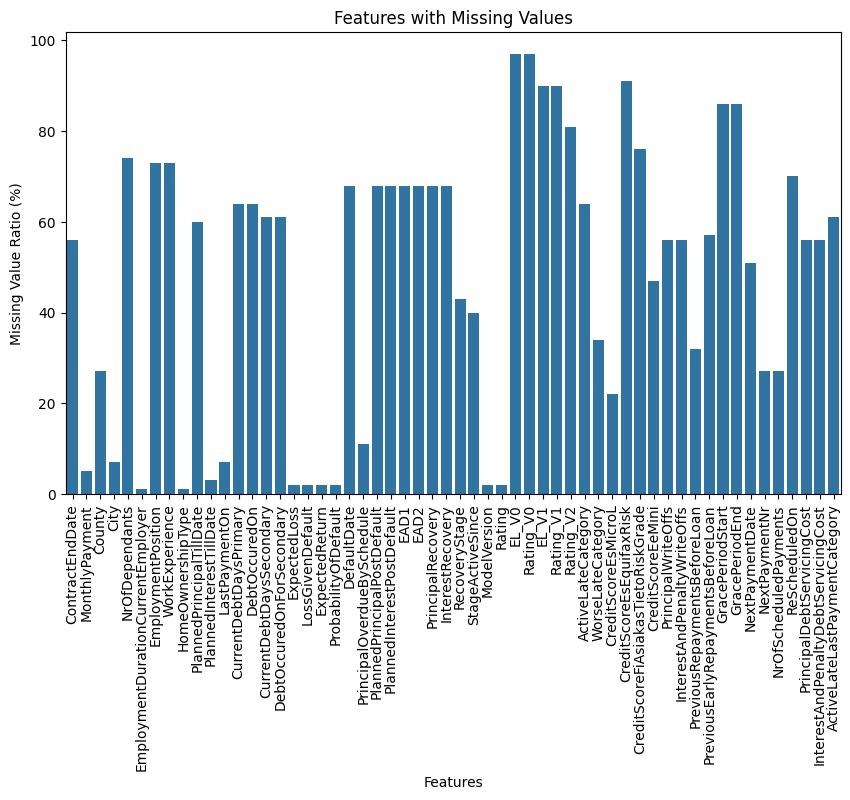

In [37]:
missing_values = round(df.isnull().sum()/len(df.index), 2)*100
features_with_missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x=features_with_missing_values.index, y=features_with_missing_values.values)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Missing Value Ratio (%)")
plt.title("Features with Missing Values")
plt.show()


# Treating missing values

In [38]:
# ==========================================
# 1. CONSTANTS & CONFIGURATIONS
# ==========================================

# Leakage, post-origination, metadata, and non-predictive ID/timestamp columns
LEAKAGE_AND_ID_COLS = [
    # Post-origination / Leakage
    "DefaultDate",
    "CurrentDebtDaysPrimary",
    "CurrentDebtDaysSecondary",
    "DebtOccuredOn",
    "DebtOccuredOnForSecondary",
    "ExpectedLoss",
    "LossGivenDefault",
    "ExpectedReturn",
    "ProbabilityOfDefault",
    "ModelVersion",
    "EL_V1",
    "PlannedPrincipalPostDefault",
    "PlannedInterestPostDefault",
    "EAD1",
    "EAD2",
    "PrincipalRecovery",
    "InterestRecovery",
    "RecoveryStage",
    "StageActiveSince",
    "PrincipalWriteOffs",
    "InterestAndPenaltyWriteOffs",
    "ActiveLateCategory",
    "WorseLateCategory",
    "ActiveLateLastPaymentCategory",
    "GracePeriodStart",
    "GracePeriodEnd",
    "NextPaymentDate",
    "NextPaymentNr",
    "NrOfScheduledPayments",
    "ReScheduledOn",
    "ContractEndDate",
    "LastPaymentOn",
    "MaturityDate_Last",
    "FirstPaymentDate",
    "PlannedPrincipalTillDate",
    "PlannedInterestTillDate",
    "PrincipalOverdueBySchedule",
    "PrincipalDebtServicingCost",
    "InterestAndPenaltyDebtServicingCost",
    "EL_V0",
    "Rating_V0",
    "Rating_V1",
    "Rating_V2",
    "EmploymentPosition",
    "City",
    "ActiveScheduleFirstPaymentReached",
    "PrincipalPaymentsMade",
    "InterestAndPenaltyPaymentsMade",
    "PrincipalBalance",
    "InterestAndPenaltyBalance",
    "Restructured",
    "MonthlyPaymentDay",  # Requested drop
    # Identifiers & Raw Timestamps
    "ReportAsOfEOD",
    "LoanId",
    "LoanNumber",
    "ListedOnUTC",
    "DateOfBirth",
    "BiddingStartedOn",
    "LoanApplicationStartedDate",
    "ApplicationSignedHour",
    "ApplicationSignedWeekday"
]

# Regional score column names
REGIONAL_SCORE_COLS = [
    "CreditScoreEsMicroL",
    "CreditScoreEsEquifaxRisk",
    "CreditScoreFiAsiakasTietoRiskGrade",
    "CreditScoreEeMini",
]

# Ordinal feature hierarchies
WORK_EXP_ORDER = [
    "Unknown",
    "LessThan2Years",
    "2To5Years",
    "5To10Years",
    "10To15Years",
    "15To25Years",
    "MoreThan25Years",
]

RATING_ORDER = ["Unrated", "HR", "F", "E", "D", "C", "B", "A", "AA"]

EMPLOYMENT_DURATION_ORDER = [
    "Other",
    "TrialPeriod",
    "UpTo1Year",
    "UpTo2Years",
    "UpTo3Years",
    "UpTo4Years",
    "UpTo5Years",
    "MoreThan5Years",
    "Retiree",
]

# Credit score rank mappings
ES_MICROL_ORDER = [f"M{i}" for i in range(10, 0, -1)]
ES_EQUIFAX_ORDER = ["D", "C", "B", "A", "AA", "AAA"]
FI_TIETO_ORDER = ["RL4", "RL3", "RL2", "RL1", "RL0"]


# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================


def encode_frequency(
    df: pd.DataFrame, column: str, fill_value: str = "Unknown"
) -> pd.DataFrame:
    """Imputes missing values and applies Frequency Encoding to a categorical column."""
    if column in df.columns:
        df[column] = df[column].fillna(fill_value)
        freq = df[column].value_counts(normalize=True)
        df[f"{column}_FreqEnc"] = df[column].map(freq)
        df.drop(columns=[column], inplace=True)
    return df


def encode_ordinal(
    df: pd.DataFrame, column: str, order: list, fill_value: str = "Other"
) -> pd.DataFrame:
    """Imputes missing values and maps categorical values to integer ranks."""
    if column in df.columns:
        df[column] = df[column].fillna(fill_value)
        mapping = {cat: i for i, cat in enumerate(order)}
        df[f"{column}_OrdEnc"] = df[column].map(mapping).fillna(0)
        df.drop(columns=[column], inplace=True)
    return df


def calculate_age(df: pd.DataFrame) -> pd.Series:
    """Calculates borrower age from DateOfBirth and ListedOnUTC."""
    if "DateOfBirth" in df.columns and "ListedOnUTC" in df.columns:
        dob = pd.to_datetime(df["DateOfBirth"], errors="coerce")
        ref_date = pd.to_datetime(df["ListedOnUTC"], errors="coerce")
        age = ((ref_date - dob).dt.days / 365.25).round()
        age = age.where((age >= 18) & (age <= 100), np.nan)
        return age.fillna(age.median())
    return pd.Series(np.nan, index=df.index)


def process_date_features(df: pd.DataFrame) -> pd.DataFrame:
  """Parses date columns, creates origination-safe duration and calendar features."""
  df["MaturityDate_Original"] = pd.to_datetime(
      df["MaturityDate_Original"], errors="coerce"
  )
  df["LoanDate"] = pd.to_datetime(df["LoanDate"], errors="coerce")

  df["LoanDurationDays"] = (
      df["MaturityDate_Original"] - df["LoanDate"]
  ).dt.days
  df["LoanDurationDays"] = df["LoanDurationDays"].fillna(
      df["LoanDurationDays"].median()
  )

  df.drop(columns=["MaturityDate_Original"], inplace=True)

  return df


def normalize_credit_scores(df: pd.DataFrame) -> pd.Series:
    """Normalizes country-specific credit score models into a unified range [0, 1]."""

    def _norm(series: pd.Series, order: list) -> pd.Series:
        mapping = {cat: i / (len(order) - 1) for i, cat in enumerate(order)}
        return series.map(mapping)

    score = pd.Series(np.nan, index=df.index, dtype="float64")

    if "Country" in df.columns:
        es_mask = df["Country"] == "ES"
        if es_mask.any():
            score.loc[es_mask] = _norm(
                df.loc[es_mask, "CreditScoreEsEquifaxRisk"], ES_EQUIFAX_ORDER
            )
            es_fallback = es_mask & score.isna()
            score.loc[es_fallback] = _norm(
                df.loc[es_fallback, "CreditScoreEsMicroL"], ES_MICROL_ORDER
            )

        fi_mask = df["Country"] == "FI"
        if fi_mask.any():
            score.loc[fi_mask] = _norm(
                df.loc[fi_mask, "CreditScoreFiAsiakasTietoRiskGrade"],
                FI_TIETO_ORDER,
            )

        ee_mask = df["Country"] == "EE"
        if ee_mask.any():
            ee_vals = df.loc[ee_mask, "CreditScoreEeMini"]
            vmin, vmax = ee_vals.min(), ee_vals.max()
            if vmax > vmin:
                score.loc[ee_mask] = (ee_vals - vmin) / (vmax - vmin)

    return score


# ==========================================
# 3. MAIN PIPELINE
# ==========================================


def preprocess_bondora_data(df: pd.DataFrame) -> pd.DataFrame:
    """Full data preprocessing pipeline for Bondora loan dataset."""
    df = df.copy()

    # --- Step 1: Feature Engineering & Date Processing ---
    df["Age"] = calculate_age(df)
    df = process_date_features(df)

    # --- Step 2: Specific Imputation & Encoding ---
    # Binary Encoding: NewCreditCustomer
    if "NewCreditCustomer" in df.columns:
        df["NewCreditCustomer"] = (
            df["NewCreditCustomer"].astype(bool).astype(int)
        )

    # Zero Imputation
    zero_fill_cols = [
        "NrOfDependants",
        "PreviousRepaymentsBeforeLoan",
        "BidsPortfolioManager",
        "BidsApi",
        "BidsManual",
        "IncomeFromPrincipalEmployer",
        "IncomeFromPension",
        "IncomeFromFamilyAllowance",
        "IncomeFromSocialWelfare",
        "IncomeFromLeavePay",
        "IncomeFromChildSupport",
        "IncomeOther",
        'PreviousEarlyRepaymentsBeforeLoan'
    ]
    for col in zero_fill_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # Ordinal Encodings
    df = encode_ordinal(
        df, "WorkExperience", WORK_EXP_ORDER, fill_value="Unknown"
    )
    df = encode_ordinal(df, "Rating", RATING_ORDER, fill_value="Unrated")
    df = encode_ordinal(
        df,
        "EmploymentDurationCurrentEmployer",
        EMPLOYMENT_DURATION_ORDER,
        fill_value="Other",
    )

    # Frequency Encodings
    df = encode_frequency(df, "County", fill_value="Unknown")
    df = encode_frequency(df, "HomeOwnershipType", fill_value="Unknown")

    # --- Step 3: Unified Credit Score Engine ---
    df["CreditScoreNormalized"] = normalize_credit_scores(df)

    if "Country" in df.columns:
        df["CreditScoreNormalized"] = df.groupby("Country")[
            "CreditScoreNormalized"
        ].transform(lambda s: s.fillna(s.median()))

    df["CreditScoreNormalized"] = df["CreditScoreNormalized"].fillna(
        df["CreditScoreNormalized"].median()
    )

    df.drop(
        columns=[c for c in REGIONAL_SCORE_COLS if c in df.columns],
        inplace=True,
    )

    # --- Step 4: One-Hot Encoding (Country & Unordered Categoricals) ---
    ohe_cols = [
        "Country",
        "LanguageCode",
        "UseOfLoan",
        "VerificationType",
        "Gender",
        "MaritalStatus",
        "EmploymentStatus",
        "OccupationArea",
    ]
    ohe_cols = [c for c in ohe_cols if c in df.columns]
    if ohe_cols:
        df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

    # Fix NrOfDependants
    df['NrOfDependants'] = df['NrOfDependants'].replace({'10Plus': '10'})
    df['NrOfDependants'] = df['NrOfDependants'].astype(int)
    # --- Step 5: Batch Imputations for Remaining Features ---
    num_cols = ["MonthlyPayment", "DebtToIncome", "FreeCash", "Education"]
    for col in num_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # --- Step 6: Clean Up Leakage, Raw Timestamps & ID Columns ---
    df.drop(
        columns=[c for c in LEAKAGE_AND_ID_COLS if c in df.columns],
        inplace=True,
    )

    print(f"Preprocessing completed successfully. Output shape: {df.shape}")
    return df


# Executing the pipeline:
loan = preprocess_bondora_data(df)

Preprocessing completed successfully. Output shape: (134529, 109)


Rationale: https://docs.google.com/spreadsheets/d/1xQew-Z0ayYiMiTslSW38VVIV3hh32-8tUqni58ZkkkY/edit?usp=sharing

In [39]:
missing_values_ratio = loan.isna().sum() / len(loan) * 100
missing_values_ratio = pd.DataFrame({'column': missing_values_ratio.index, 'ratio': missing_values_ratio.values})
missing_values_ratio[missing_values_ratio['ratio'] > 0]

,column,ratio


## Creating Target Variable

Here, status is the variable which help us in creating target variable. The reason for not making status as target variable is that it has three unique values **current, Late and repaid**. There is no default feature but there is a feature **default date** which tells us when the borrower has defaulted means on which date the borrower defaulted. So, we will be combining **Status** and **Default date** features for creating target  variable.The reason we cannot simply treat Late as default because it also has some records in which actual status is Late but the user has never defaulted i.e., default date is null.
So we will first filter out all the current status records because they are not matured yet they are current loans.

In [40]:
loan['Status'].value_counts()

,count
Status,
Current,57135
Late,45772
Repaid,31622


In [41]:
# filtering out Current Status records
loan = loan[loan['Status'] != 'Current']

Now, we will create new target variable in which 0 will be assigned when default date is null means borrower has never defaulted while 1 in case default date is present.

In [42]:
loan["Default"] = loan['Status'].apply(lambda x: 0 if x=='Repaid' else 1)
loan = loan.drop(['Status'],axis=1)
loan['Default'].value_counts()

,count
Default,
1,45772
0,31622


In [43]:
loan.head(3)

,BidsPortfolioManager,BidsApi,BidsManual,UserName,NewCreditCustomer,LoanDate,Age,AppliedAmount,Amount,Interest,...,OccupationArea_11.0,OccupationArea_12.0,OccupationArea_13.0,OccupationArea_14.0,OccupationArea_15.0,OccupationArea_16.0,OccupationArea_17.0,OccupationArea_18.0,OccupationArea_19.0,Default
0,0,0,115.0410,KARU,1,2009-06-16,62.0,319.5582,115.0408,30.0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,140.6057,koort681,0,2009-06-15,49.0,191.7349,140.6057,25.0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,319.5580,0ie,1,2009-06-15,59.0,319.5582,319.5409,25.0,...,0,0,0,0,0,0,0,0,0,1


In [44]:
loan.shape

(77394, 109)

Checking distribution of categorical variables

checking distribution of all numeric columns

In [45]:
loan.describe()

,BidsPortfolioManager,BidsApi,BidsManual,NewCreditCustomer,LoanDate,Age,AppliedAmount,Amount,Interest,LoanDuration,...,OccupationArea_11.0,OccupationArea_12.0,OccupationArea_13.0,OccupationArea_14.0,OccupationArea_15.0,OccupationArea_16.0,OccupationArea_17.0,OccupationArea_18.0,OccupationArea_19.0,Default
count,77394.000000,77394.000000,77394.000000,77394.000000,77394,77394.000000,77394.000000,77394.000000,77394.00000,77394.000000,...,77394.000000,77394.000000,77394.000000,77394.000000,77394.000000,77394.000000,77394.000000,77394.000000,77394.000000,77394.000000
mean,1221.504303,32.766506,563.032056,0.631406,2017-04-05 00:18:46.412900352,40.138564,2746.981169,2472.673771,40.30165,44.425498,...,0.013619,0.005595,0.006370,0.010311,0.020092,0.016164,0.028245,0.006771,0.011538,0.591415
min,0.000000,0.000000,0.000000,0.000000,2009-02-28 00:00:00,18.000000,31.955800,6.390000,3.00000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,246.000000,0.000000,19.000000,0.000000,2015-12-11 00:00:00,30.000000,740.000000,740.000000,23.42000,36.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,613.000000,0.000000,283.000000,1.000000,2017-09-25 00:00:00,38.000000,2125.000000,2020.000000,31.95500,48.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,1629.000000,5.000000,745.000000,1.000000,2018-12-28 00:00:00,49.000000,3720.000000,3185.000000,50.33000,60.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,10625.000000,7570.000000,10630.000000,1.000000,2020-01-23 00:00:00,77.000000,10632.000000,10632.000000,264.31000,60.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,1531.208800,163.557245,821.757218,0.482427,NaN,12.148759,2463.487043,2163.710046,30.61795,16.412387,...,0.115902,0.074589,0.079558,0.101018,0.140316,0.126107,0.165673,0.082005,0.106796,0.491575


In [46]:
def count_outliers_zscore(df, threshold=3):
    """
    Counts the number of outliers in each column of a DataFrame based on the Z-score method.

    Parameters:
    - df (pd.DataFrame): The input DataFrame
    - threshold (float): The Z-score threshold to identify outliers (default is 3)

    Returns:
    - pd.Series: A series with column names as the index and the number of outliers as the values.
    """
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])

    # Calculate Z-scores
    z_scores = (numeric_df - numeric_df.mean()) / numeric_df.std()

    # Count outliers for each column
    outlier_counts = (np.abs(z_scores) > threshold).sum()

    return outlier_counts

def replace_outliers_with_median(df, features,threshold=3):
    """
    Replaces outliers in each numeric column of a DataFrame with the column median based on the Z-score method.

    Parameters:
    - df (pd.DataFrame): The input DataFrame
    - threshold (float): The Z-score threshold to identify outliers (default is 3)

    Returns:
    - pd.DataFrame: The updated DataFrame with outliers replaced by the median.
    - list: List of features containing outliers.
    """
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])

    # Calculate Z-scores
    z_scores = (numeric_df - numeric_df.mean()) / numeric_df.std()

    # Identify columns with outliers
    features_with_outliers = features

    # Replace outliers with median
    for col in features_with_outliers:
        median_value = df[col].median()
        df[col] = np.where(np.abs(z_scores[col]) > threshold, median_value, df[col])

    return df, features_with_outliers

In [47]:
outliers = count_outliers_zscore(loan)

In [48]:
# 1. Tính toán tỉ lệ % outliers cho từng cột numeric
total_rows = len(loan)
outliers_pct = (outliers / total_rows) * 100

# 2. Lọc các features có tỉ lệ outliers > 5% và sắp xếp giảm dần
high_outliers = outliers_pct[outliers_pct > 5].sort_values(ascending=False)

# 3. Hiển thị danh sách
print(f"Tổng số features có outliers > 5%: {len(high_outliers)}\n")
print(high_outliers.round(2).astype(str) + "%")

Tổng số features có outliers > 5%: 4

OccupationArea_1.0    9.87%
LanguageCode_3        8.44%
UseOfLoan_0           8.29%
Gender_2.0             7.4%
dtype: object


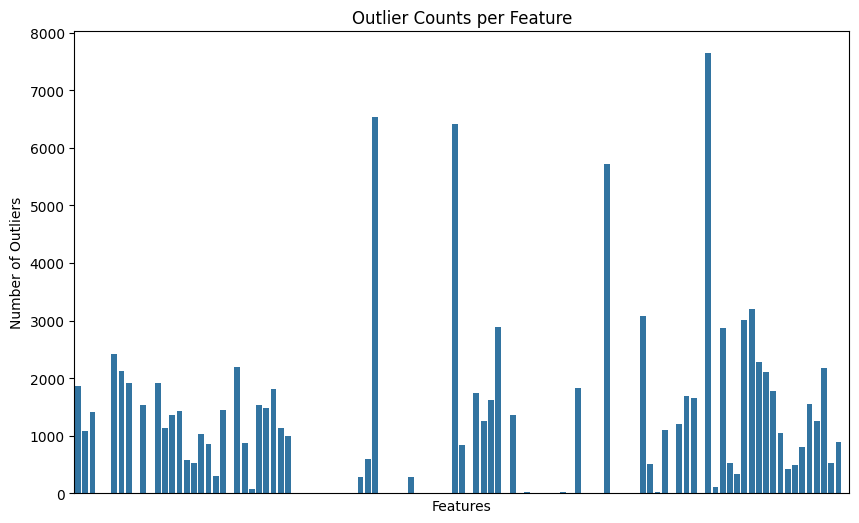

In [49]:
plt.figure(figsize=(10, 6))
sns.barplot(x=outliers.index, y=outliers.values)
plt.xticks([])
plt.xlabel("Features")
plt.ylabel("Number of Outliers")
plt.title("Outlier Counts per Feature")
plt.show()

In [50]:
outliers_list = outliers[outliers > 0].index.tolist()
clean_loan, features_with_outliers = replace_outliers_with_median(loan, outliers_list)

In [51]:
clean_loan.to_csv('/content/drive/MyDrive/Research/Paper: Enhancing Default Prediction in P2P Lending with Deep Model Fusion/Source Code/data/clean/clean_df.csv', index=False)